In [ ]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_graphviz, DecisionTreeRegressor
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [ ]:
iris = datasets.load_iris(as_frame=True)
X = iris.data
y = iris.target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
accuracy = knn.score(X_test, y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("Score:", knn.score(X_test, y_test))
print("Predictions:", knn.predict(X_test))
print("True labels:", y_test[:5])

Accuracy: 100.00%
Score: 1.0
Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
True labels: 73     1
18     0
118    2
78     1
76     1
Name: target, dtype: int64


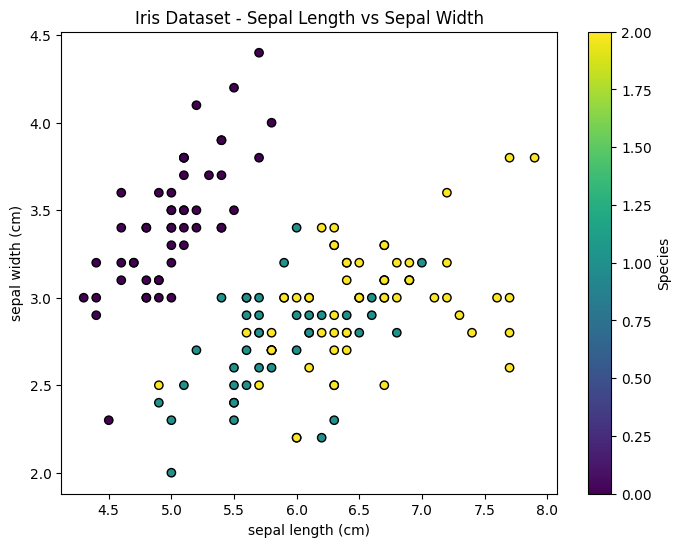

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X.to_numpy()[:, 0], X.to_numpy()[:, 1], c=y, cmap='viridis', edgecolor='k')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('Iris Dataset - Sepal Length vs Sepal Width')
plt.colorbar(label='Species')
plt.show()

In [ ]:
tree_clf = DecisionTreeClassifier(random_state=42, max_depth=3)
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
print(f"Decision Tree Accuracy: {tree_clf.score(X_test, y_test) * 100:.2f}%")

Decision Tree Accuracy: 100.00%


In [ ]:
print("predict proba", tree_clf.predict_proba(X_test[:5]))

predict proba [[0.         1.         0.        ]
 [1.         0.         0.        ]
 [0.         0.02857143 0.97142857]
 [0.         1.         0.        ]
 [0.         0.5        0.5       ]]


In [ ]:
export_graphviz(
    tree_clf,
    out_file="iris_tree.dot",
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    rounded=True,
)

In [ ]:
X_moons, y_moons = datasets.make_moons(n_samples=100, noise=0.1, random_state=42)
X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(X_moons, y_moons, test_size=0.2, random_state=42)

In [ ]:
tree_clf1 = DecisionTreeClassifier(random_state=42, max_depth=3)
tree_clf1.fit(X_moons_train, y_moons_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
tree_clf2 = DecisionTreeClassifier(random_state=42, max_depth=5)
tree_clf2.fit(X_moons_train, y_moons_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
predictions = tree_clf1.predict(X_moons_test)
accuracy_tree = accuracy_score(y_moons_test, predictions)

In [ ]:
print(f"Decision Tree 1 Accuracy: {tree_clf1.score(X_moons_test, y_moons_test) * 100:.2f}%")
print(f"Decision Tree 2 Accuracy: {tree_clf2.score(X_moons_test, y_moons_test) * 100:.2f}%")

Decision Tree 1 Accuracy: 100.00%
Decision Tree 2 Accuracy: 100.00%


In [ ]:
np.random.seed(42)
X_quad = np.random.rand(200, 1) - 0.5
y_quad = X_quad ** 2 + 0.025 * np.random.randn(200, 1)

tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X_quad, y_quad)


DecisionTreeRegressor(max_depth=2, random_state=42)

In [ ]:
predictions = tree_clf.predict(X_test)
accuracy_tree = accuracy_score(y_test, predictions)

In [ ]:
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y,
random_state=42)
voting_clf = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(random_state=42)),
        ("rf", RandomForestClassifier(random_state=42)),
        ("svc", SVC(random_state=42)),
    ]
)
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('svc', SVC(random_state=42))])

In [ ]:
for name, clf in voting_clf.named_estimators_.items():
    print(name, "=", clf.score(X_test, y_test))

lr = 0.864
rf = 0.896
svc = 0.896


In [ ]:
voting_clf.predict(X_test[:1])

array([1])

In [ ]:
[clf.predict(X_test[:1]) for clf in voting_clf.estimators_]

[array([1]), array([1]), array([0])]

In [ ]:
voting_clf.score(X_test, y_test)

0.912

In [ ]:
from sklearn.ensemble import BaggingClassifier


bag_clf = BaggingClassifier(DecisionTreeClassifier(),
n_estimators=500, oob_score=True,
n_jobs=-1, random_state=42)
bag_clf.fit(X_train, y_train)
bag_clf.oob_score_

0.896

In [ ]:
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.92

In [ ]:
bag_clf.oob_decision_function_[:3]

array([[0.32352941, 0.67647059],
       [0.3375    , 0.6625    ],
       [1.        , 0.        ]])

In [ ]:
rnd_clf = RandomForestClassifier(n_estimators=500,
random_state=42)
rnd_clf.fit(iris.data, iris.target)
for score, name in zip(rnd_clf.feature_importances_,
    iris.data.columns):
    print(round(score, 2), name)

0.11 sepal length (cm)
0.02 sepal width (cm)
0.44 petal length (cm)
0.42 petal width (cm)


In [ ]:
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding
X_swiss, t = make_swiss_roll(n_samples=1000, noise=0.2,
random_state=42)
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10,
random_state=42)
X_unrolled = lle.fit_transform(X_swiss)